In [1]:
import torch
import torch.nn as nn
from networks import FullyConnectedNN, NoisyFullyConnectedNN, FixNoiseFullyConnectedNN, DropoutFullyConnectedNN
import os
import pandas as pd
import numpy as np
from utils import *
import shutil
import itertools
from config import configs
from matplotlib import pyplot as plt
from tqdm import tqdm

{'datasets': ['protein-tertiary-structure'], 'models': ['noisyFCN'], 'optimizer_name': 'Adam', 'hyperparam_eval_interval': 10, 'patience': 3, 'global_max_epochs': 2000, 'dropout_probs': [0.2, 0.1, 0.05, 0.01, 0.005, 0.001], 'fix_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'init_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'batch_sizes': [32], 'batch_sizes_specific': {'energy': [32]}, 'weight_decays': [0.01], 'dropout_batch_size': 32, 'n_hidden': 2, 'nonlinearity': 'relu', 'learning_rates': [0.002], 'mc_samples': 500, 'num_units': 50, 'num_units_specific': {'protein-tertiary-structure': 100}, 'normalize_X': True, 'normalize_y': True, 'n_folds': 5, 'inverted_cv_fraction': 5}


In [2]:
def def_optm(optimizer_name, normal_param, alpha_param, learning_rate, momentum=0, weight_decay=None):
    if optimizer_name == "SGD":
        print("using SGD as optimizer")
        optimizer = torch.optim.SGD([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate,
                                    momentum=momentum, weight_decay=weight_decay,
                                    nesterov=True)

    elif optimizer_name == "Adam":
        print("using Adam as optimizer")
        optimizer = torch.optim.Adam([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate,
                                    weight_decay=weight_decay)
    elif optimizer_name == "RMSprop":
        print("using RMSprop as optimizer")
        optimizer = torch.optim.RMSprop([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate, alpha=0.99, eps=1e-08, weight_decay=weight_decay, momentum=0)
    return optimizer

In [3]:
num_sample = 20
np.random.seed(123)
x = np.random.uniform(-4, 4, num_sample)
eps = np.random.normal(0, 3, num_sample)
y = x**3 + eps

In [4]:
x = x[:, np.newaxis]
y = y[:, np.newaxis]

In [5]:
X = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
train_data = torch.utils.data.TensorDataset(X, y)
batch_size = len(X)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=4)

In [6]:
# ['FCN', 'noisyFCN', 'fixnoiseFCN', 'dropoutFCN']
model_name = "dropoutFCN"
input_size = X.shape[1]
hidden_sizes = [100]
output_size = 1
init_noiselevel, fix_noiselevel, dropout_prob = 0.1, 0.1, 0.2

In [7]:
model = def_model(model_name, input_size, hidden_sizes, output_size, init_noiselevel, fix_noiselevel, dropout_prob)

model_name dropoutFCN


In [8]:
normal_param = [
    param for name, param in model.named_parameters()
    if (not 'alpha_' in name and not 'alphafix_' in name)
] # this is the parameters do not contain noise scale coefficient
alpha_param = [
    param for name, param in model.named_parameters()
    if 'alpha_' in name
]
criterion = nn.MSELoss()
use_cuda = torch.cuda.is_available()
if use_cuda:
    model.cuda()
    criterion.cuda()

learning_rate = 0.02
momentum = 0.9
weight_decay = 0
optimizer_name = "Adam"
optimizer = def_optm(optimizer_name, normal_param, alpha_param, learning_rate, weight_decay=weight_decay)

using Adam as optimizer


In [9]:
global_max_epochs = 500

In [10]:
train_losses = []
for epoch in tqdm(range(global_max_epochs)):
    train_loss = train(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, use_cuda=use_cuda)
    print('epoch: {}, train_loss: {:.4f}'.format(epoch, train_loss))
    train_losses.append(train_loss)

  0%|          | 1/500 [00:00<06:25,  1.29it/s]

epoch: 0, train_loss: 312.4382


  0%|          | 2/500 [00:01<04:26,  1.87it/s]

epoch: 1, train_loss: 280.6055


  1%|          | 3/500 [00:01<03:44,  2.22it/s]

...

epoch: 497, train_loss: 6.3173


100%|█████████▉| 499/500 [02:33<00:00,  4.57it/s]

epoch: 498, train_loss: 5.7283


100%|██████████| 500/500 [02:33<00:00,  3.25it/s]

epoch: 499, train_loss: 5.7179


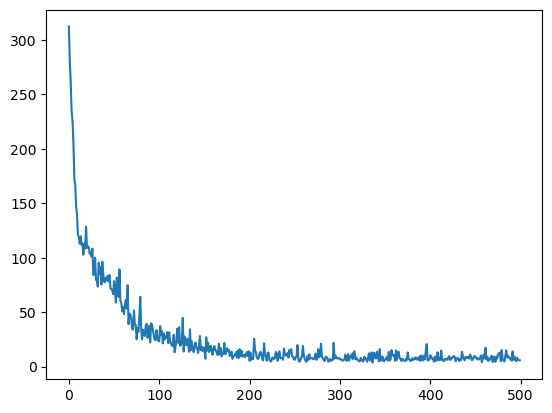

In [11]:
plt.plot(train_losses)

In [12]:
new_x = np.linspace(-6,6,100)
new_y = new_x ** 3
new_x = new_x[:, np.newaxis]
new_X = torch.tensor(new_x, dtype=torch.float32)
new_X = new_X.cuda()
new_y = torch.tensor(new_y, dtype=torch.float32)

In [13]:
test_data = torch.utils.data.TensorDataset(new_X, new_y)
batch_size = len(new_X)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

In [14]:
def validate(model, val_loader, criterion, test_times=100, use_cuda=False):
    model.eval()
    if 'Dropout' in model._get_name():
        recursive_module_iteration(model)
    losses = AverageMeter()
    with torch.no_grad():
        var_outputs_all = []
        pred_all = []
        for inputs, labels in val_loader:
            outputs = torch.zeros((inputs.shape[0], 1, test_times))
            if use_cuda:
                labels = labels.cuda()
                inputs = inputs.cuda()
                outputs = outputs.cuda()
            # compute output
            for i in range(test_times):
                output = model(inputs)
                outputs[:, :, i] = output
            avg_outputs = torch.mean(outputs, dim=2)
            var_outputs = torch.sum(torch.var(outputs, dim=2), dim=-1)
            loss = criterion(avg_outputs, labels)
            losses.update(loss.item(), inputs.size(0))
            if use_cuda:
                var_outputs = var_outputs.cpu()
                avg_outputs = avg_outputs.cpu()
            var_outputs = var_outputs.numpy().tolist()
            var_outputs_all.extend(var_outputs)
            avg_outputs = avg_outputs.numpy().tolist()
            pred_all.extend(avg_outputs)
            
    return losses.avg, var_outputs_all, pred_all

In [15]:
loss, var_all, pred_all = validate(model, test_loader, criterion, test_times=500, use_cuda=False)

Module: DropoutFullyConnectedNN
  Module: ModuleList
    Module: Linear
    Module: Linear
  Module: ModuleList
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
  Module: ReLU


/home/xueqiong/anaconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([100])) that is different to the input size (torch.Size([100, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


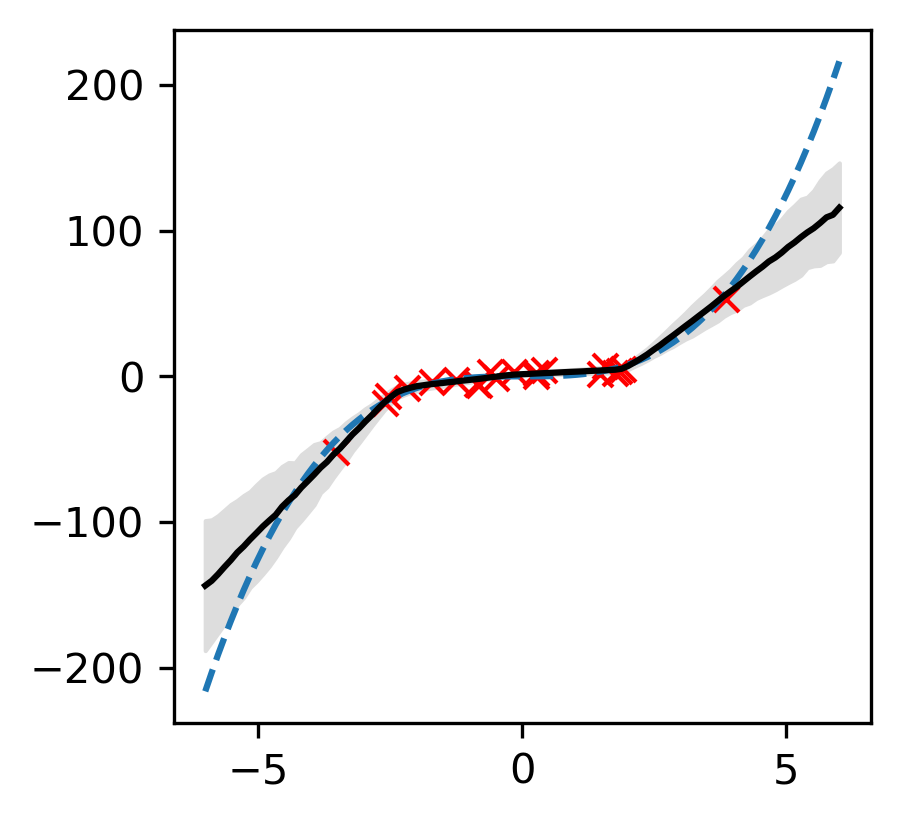

In [16]:
plt.figure(figsize=[3, 3], dpi=300)
plt.plot(x.flatten(), y.detach().cpu().numpy().flatten(), 'rx')
plt.plot(new_x.flatten(), new_x.flatten()**3, linestyle='--')
mean_sample = np.asarray(pred_all).flatten()
std = np.sqrt(var_all)
plt.plot(new_x[:, 0], mean_sample, 'k-')
plt.gca().fill_between(new_x[:, 0], mean_sample-3*std, mean_sample+3*std,
                           color="#dddddd")
plt.show()

In [17]:
np.sqrt(np.mean((new_x.flatten()**3-mean_sample)**2))

26.202352355048998

In [18]:
mean_standardized_log_loss(new_x.flatten()**3, mean_sample, std, sample_weight=None, multioutput="uniform_average", squared=True)

7.237540972205215

In [19]:
dropout_prob

0.2